# Centrality vs Efficient – Comparative Analysis

This notebook compares evacuation performance across four strategies:
- low awareness + efficient
- low awareness + centrality
- high awareness + efficient
- high awareness + centrality

Goal:
Assess whether centrality-based routing provides systematic advantages over efficient routing,
and whether such advantages depend on the awareness level.

Input:
One or more CSV files exported from `experiment_metrics` from `results\CSV`.

In [20]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Optional (pretty display in notebooks)
from IPython.display import display

In [21]:
def plot_value_counts(series, title, xlabel, ylabel, outname=None, figsize=(5, 4)):
    """
    Plots a bar chart of value counts of a pandas Series.
    """
    counts = series.value_counts()

    plt.figure(figsize=figsize)
    plt.bar(counts.index.astype(str), counts.values)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()

    if outname:
        plt.savefig(f"../results/images/{outname}.pdf", dpi=300)
        plt.savefig(f"../results/images/{outname}.png", dpi=300)
    plt.show()

In [22]:
import pandas as pd

def trend_summary_to_strategy_df(
    trend_summary: pd.DataFrame,
    low_col: str,
    high_col: str,
    centrality_label="Centrality",
    efficient_label="Efficient"
) -> pd.DataFrame:
    """
    Converts a yes/no trend summary into a strategy-vs-awareness table.

    Returns:
        DataFrame with index = ["Low Awareness", "High Awareness"]
        columns = ["Centrality", "Efficient"]
    """
    data = {
        centrality_label: [
            trend_summary.loc["yes", low_col],
            trend_summary.loc["yes", high_col],
        ],
        efficient_label: [
            trend_summary.loc["no", low_col],
            trend_summary.loc["no", high_col],
        ],
    }

    return pd.DataFrame(
        data,
        index=["Low Awareness", "High Awareness"]
    )


In [23]:
def plot_centrality_vs_efficient_three_way(
    strategy_df: pd.DataFrame,
    title: str,
    ylabel: str = "Number of Cases",
    outname: str | None = None,
    figsize=(6.5, 4),
    show_values=True
):
    labels = strategy_df.index.tolist()
    x = np.arange(len(labels))

    strategies = ["Centrality", "Efficient", "Equal"]
    n = len(strategies)
    width = 0.75 / n   # total bar width = 0.75

    plt.figure(figsize=figsize)

    bars = []
    for i, s in enumerate(strategies):
        if s not in strategy_df.columns:
            continue

        offsets = x + (i - (n - 1) / 2) * width
        b = plt.bar(offsets, strategy_df[s].values, width, label=s)
        bars.append(b)

        if show_values:
            for bar in b:
                h = bar.get_height()
                plt.text(
                    bar.get_x() + bar.get_width() / 2,
                    h,
                    f"{int(h)}",
                    ha="center",
                    va="bottom",
                    fontsize=9
                )

    plt.xticks(x, labels)
    plt.xlabel("Situational Awareness Level")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if outname:
        plt.savefig(f"../results/images/{outname}.pdf", dpi=300)
        plt.savefig(f"../results/images/{outname}.png", dpi=300)

    plt.show()


## 1) Load one CSV (edit path)


In [24]:
# path = "../results/CSV/Cruise_Ship_experiment_metrics.csv"
path = "../results/CSV/Theme Park_experiment_metrics.csv"
# path = "../results/CSV/corridor_experiment_metrics.csv"

df = pd.read_csv(path)
display(df.head())


,experiment_id,case_name,agent_group_id,algorithm,awareness,n_records,mean_remaining_path_risk,remaining_path_risk_var,cumulative_risk_exposure,avg_path_length,min_time,avg_time,median_time,p90_time,max_time,case_name.1,risk_nodes,source_nodes,agents_per_source,random_seed
0,2,theme_park_case_1,18,Centrality,High,25,0.032067,0.003240,0.054667,1.920000,10.05,13.705,13.695,16.680,17.37,theme_park_case_1,"[[0, ""67"", 1.0], [0, ""54"", 1.0], [0, ""28"", 1.0...","[""69"", ""51"", ""18"", ""30""]","[13, 7, 6, 4]",2468
1,2,theme_park_case_1,18,Centrality,Low,27,0.029691,0.003000,0.068025,1.851852,10.05,13.515,13.455,16.350,17.25,theme_park_case_1,"[[0, ""67"", 1.0], [0, ""54"", 1.0], [0, ""28"", 1.0...","[""69"", ""51"", ""18"", ""30""]","[13, 7, 6, 4]",2468
2,2,theme_park_case_1,18,Efficient,High,25,0.032067,0.003240,0.054667,1.920000,10.05,13.705,13.695,16.680,17.37,theme_park_case_1,"[[0, ""67"", 1.0], [0, ""54"", 1.0], [0, ""28"", 1.0...","[""69"", ""51"", ""18"", ""30""]","[13, 7, 6, 4]",2468
3,2,theme_park_case_1,18,Efficient,Low,27,0.029691,0.003000,0.068025,1.851852,10.05,13.515,13.455,16.350,17.25,theme_park_case_1,"[[0, ""67"", 1.0], [0, ""54"", 1.0], [0, ""28"", 1.0...","[""69"", ""51"", ""18"", ""30""]","[13, 7, 6, 4]",2468
4,2,theme_park_case_1,30,Centrality,High,25,0.044789,0.005947,0.054667,3.280000,13.80,15.765,15.765,17.334,17.73,theme_park_case_1,"[[0, ""67"", 1.0], [0, ""54"", 1.0], [0, ""28"", 1.0...","[""69"", ""51"", ""18"", ""30""]","[13, 7, 6, 4]",2468


## 2) Inspect columns (debug cell)

In [25]:
print("Columns in the dataset:")
for col in df.columns:
    print(f"- {col}")

Columns in the dataset:
- experiment_id
- case_name
- agent_group_id
- algorithm
- awareness
- n_records
- mean_remaining_path_risk
- remaining_path_risk_var
- cumulative_risk_exposure
- avg_path_length
- min_time
- avg_time
- median_time
- p90_time
- max_time
- case_name.1
- risk_nodes
- source_nodes
- agents_per_source
- random_seed


## 3) Basic cleanup & normalization
- Remove duplicated join artifact: `case_name.1` if present
- Normalize text fields (lowercase) for stable pivoting
- Ensure numeric KPI columns are numeric

In [26]:
# Drop duplicated case_name column created by joins
if "case_name.1" in df.columns:
    df = df.drop(columns=["case_name.1"])

# Normalize algorithm/awareness to lowercase (safe even if already lowercase)
df["algorithm"] = df["algorithm"].astype(str).str.strip().str.lower()
df["awareness"] = df["awareness"].astype(str).str.strip().str.lower()
df["case_name"] = df["case_name"].astype(str).str.strip()

# Build strategy label (you already have "strategy" column, but we rebuild it deterministically)
df["strategy"] = df["awareness"] + " awareness + " + df["algorithm"]

# Ensure numeric columns are numeric (coerce errors to NaN)
numeric_cols = [
    "n_records",
    "mean_remaining_path_risk",
    "remaining_path_risk_var",
    "cumulative_risk_exposure",
    "avg_path_length",
    "min_time",
    "avg_time",
    "median_time",
    "p90_time",
    "max_time",
    "random_seed",
]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

display(df.head())

,experiment_id,case_name,agent_group_id,algorithm,awareness,n_records,mean_remaining_path_risk,remaining_path_risk_var,cumulative_risk_exposure,avg_path_length,min_time,avg_time,median_time,p90_time,max_time,risk_nodes,source_nodes,agents_per_source,random_seed,strategy
0,2,theme_park_case_1,18,centrality,high,25,0.032067,0.003240,0.054667,1.920000,10.05,13.705,13.695,16.680,17.37,"[[0, ""67"", 1.0], [0, ""54"", 1.0], [0, ""28"", 1.0...","[""69"", ""51"", ""18"", ""30""]","[13, 7, 6, 4]",2468,high awareness + centrality
1,2,theme_park_case_1,18,centrality,low,27,0.029691,0.003000,0.068025,1.851852,10.05,13.515,13.455,16.350,17.25,"[[0, ""67"", 1.0], [0, ""54"", 1.0], [0, ""28"", 1.0...","[""69"", ""51"", ""18"", ""30""]","[13, 7, 6, 4]",2468,low awareness + centrality
2,2,theme_park_case_1,18,efficient,high,25,0.032067,0.003240,0.054667,1.920000,10.05,13.705,13.695,16.680,17.37,"[[0, ""67"", 1.0], [0, ""54"", 1.0], [0, ""28"", 1.0...","[""69"", ""51"", ""18"", ""30""]","[13, 7, 6, 4]",2468,high awareness + efficient
3,2,theme_park_case_1,18,efficient,low,27,0.029691,0.003000,0.068025,1.851852,10.05,13.515,13.455,16.350,17.25,"[[0, ""67"", 1.0], [0, ""54"", 1.0], [0, ""28"", 1.0...","[""69"", ""51"", ""18"", ""30""]","[13, 7, 6, 4]",2468,low awareness + efficient
4,2,theme_park_case_1,30,centrality,high,25,0.044789,0.005947,0.054667,3.280000,13.80,15.765,15.765,17.334,17.73,"[[0, ""67"", 1.0], [0, ""54"", 1.0], [0, ""28"", 1.0...","[""69"", ""51"", ""18"", ""30""]","[13, 7, 6, 4]",2468,high awareness + centrality


## 4) Sanity checks
Ensure the four expected combinations exist:
- low/efficient, low/centrality, high/efficient, high/centrality

In [27]:
pivot_avg = df.pivot_table(
    index="case_name",
    columns=["awareness", "algorithm"],  # ahora son 'low'/'high' y 'centrality'/'efficient'
    values="avg_time",
    aggfunc="mean"
)

display(pivot_avg.head())

# LOW awareness
low_c = pivot_avg[("low", "centrality")]
low_e = pivot_avg[("low", "efficient")]

low_c_better = low_c < low_e
low_e_better = low_c > low_e
low_equal = low_c == low_e

# HIGH awareness
high_c = pivot_avg[("high", "centrality")]
high_e = pivot_avg[("high", "efficient")]

high_c_better = high_c < high_e
high_e_better = high_c > high_e
high_equal = high_c == high_e


awareness                            high                   low           
algorithm                      centrality  efficient centrality  efficient
case_name                                                                 
representative_case_theme_park  21.521957  21.521957  22.318207  28.935536
theme_park_case_1               19.851786  19.851786  20.822576  20.822576
theme_park_case_10              24.055821  22.889393  24.055821  23.913179
theme_park_case_2               17.265683  17.476933  17.265683  20.231760
theme_park_case_3               16.377054  16.377054  16.377054  18.437054

In [28]:
expected = {
    ("low", "efficient"),
    ("low", "centrality"),
    ("high", "efficient"),
    ("high", "centrality"),
}
present = set(zip(df["awareness"], df["algorithm"]))
missing = expected - present

print("Present (awareness, algorithm) pairs:", sorted(present))
if missing:
    print("⚠️ Missing expected pairs:", sorted(missing))
else:
    print("✅ All four expected strategy combinations are present.")

Present (awareness, algorithm) pairs: [('high', 'centrality'), ('high', 'efficient'), ('low', 'centrality'), ('low', 'efficient')]
✅ All four expected strategy combinations are present.


## 5) Global summary (aggregate across all cases)
This answers: "Overall, which strategy tends to be better?"

In [29]:
summary_global = (
    df
    .groupby("strategy", as_index=False)
    .agg(
        n_rows=("case_name", "size"),
        n_cases=("case_name", "nunique"),
        avg_time_mean=("avg_time", "mean"),
        avg_time_median=("avg_time", "median"),
        median_time_mean=("median_time", "mean"),
        p90_time_mean=("p90_time", "mean"),
        max_time_mean=("max_time", "mean"),
        min_time_mean=("min_time", "mean"),
        risk_exposure_mean=("cumulative_risk_exposure", "mean"),
        remaining_risk_mean=("mean_remaining_path_risk", "mean"),
    )
    .sort_values(["avg_time_mean", "p90_time_mean"], ascending=True)
)

display(summary_global)

,strategy,n_rows,n_cases,avg_time_mean,avg_time_median,median_time_mean,p90_time_mean,max_time_mean,min_time_mean,risk_exposure_mean,remaining_risk_mean
1,high awareness + efficient,36,11,20.173121,19.439000,20.269583,23.541000,24.390000,15.719167,0.039284,0.030489
0,high awareness + centrality,36,11,20.283419,19.448000,20.376667,23.635250,24.482500,15.885000,0.036183,0.029524
2,low awareness + centrality,36,11,20.643516,19.827000,20.737917,23.941917,24.779167,16.331667,0.038018,0.033588
3,low awareness + efficient,36,11,22.982362,20.402143,23.075417,26.531750,27.375833,18.290833,0.045726,0.045127


## 6) Case-wise comparison (centrality vs efficient within each awareness)
This answers: "In case X, was centrality better than efficient? Does the trend repeat?"

In [30]:
# Add boolean indicators: centrality better than efficient
# (lower time is better)
pivot_avg["low: centrality better"] = pivot_avg[("low", "centrality")] < pivot_avg[("low", "efficient")]
pivot_avg["high: centrality better"] = pivot_avg[("high", "centrality")] < pivot_avg[("high", "efficient")]

# Also compute deltas (efficient - centrality): positive means centrality is better (smaller time)
pivot_avg["low: Δ(efficient - centrality)"] = pivot_avg[("low", "efficient")] - pivot_avg[("low", "centrality")]
pivot_avg["high: Δ(efficient - centrality)"] = pivot_avg[("high", "efficient")] - pivot_avg[("high", "centrality")]

display(pivot_avg)

awareness                            high                   low             \
algorithm                      centrality  efficient centrality  efficient   
case_name                                                                    
representative_case_theme_park  21.521957  21.521957  22.318207  28.935536   
theme_park_case_1               19.851786  19.851786  20.822576  20.822576   
theme_park_case_10              24.055821  22.889393  24.055821  23.913179   
theme_park_case_2               17.265683  17.476933  17.265683  20.231760   
theme_park_case_3               16.377054  16.377054  16.377054  18.437054   
theme_park_case_4               17.231161  17.231161  18.682411  18.682411   
theme_park_case_5               16.448036  16.448036  16.448036  16.448036   
theme_park_case_6               25.837582  25.837582  25.882747  28.556868   
theme_park_case_7               25.652967  25.652967  25.652967  27.709121   
theme_park_case_8               24.054000  23.979000  24.054000  23.979000   
theme_park_case_9               24.054000  24.054000  24.054000  38.496429   

awareness                      low: centrality better high: centrality better  \
algorithm                                                                       
case_name                                                                       
representative_case_theme_park                   True                   False   
theme_park_case_1                               False                   False   
theme_park_case_10                              False                   False   
theme_park_case_2                                True                    True   
theme_park_case_3                                True                   False   
theme_park_case_4                               False                   False   
theme_park_case_5                               False                   False   
theme_park_case_6                                True                   False   
theme_park_case_7                                True                   False   
theme_park_case_8                               False                   False   
theme_park_case_9                                True                   False   

awareness                      low: Δ(efficient - centrality)  \
algorithm                                                       
case_name                                                       
representative_case_theme_park                       6.617328   
theme_park_case_1                                    0.000000   
theme_park_case_10                                  -0.142643   
theme_park_case_2                                    2.966077   
theme_park_case_3                                    2.060000   
theme_park_case_4                                    0.000000   
theme_park_case_5                                    0.000000   
theme_park_case_6                                    2.674121   
theme_park_case_7                                    2.056154   
theme_park_case_8                                   -0.075000   
theme_park_case_9                                   14.442429   

awareness                      high: Δ(efficient - centrality)  
algorithm                                                       
case_name                                                       
representative_case_theme_park                        0.000000  
theme_park_case_1                                     0.000000  
theme_park_case_10                                   -1.166429  
theme_park_case_2                                     0.211250  
theme_park_case_3                                     0.000000  
theme_park_case_4                                     0.000000  
theme_park_case_5                                     0.000000  
theme_park_case_6                                     0.000000  
theme_park_case_7                                     0.000000  
theme_park_case_8                                    -0.075000  
theme_park_case_

## 7) Trend counts (how often centrality wins)
This is a strong "study result" summary.

In [31]:
trend_time_summary = pd.DataFrame(
    {
        "low awareness": [
            int(low_c_better.sum()),
            int(low_e_better.sum()),
            int(low_equal.sum()),
        ],
        "high awareness": [
            int(high_c_better.sum()),
            int(high_e_better.sum()),
            int(high_equal.sum()),
        ],
    },
    index=["Centrality better", "Efficient better", "Equal"],
)

display(trend_time_summary)

,low awareness,high awareness
Centrality better,6,1
Efficient better,2,2
Equal,3,8


,Centrality,Efficient,Equal
Low Awareness,6,2,3
High Awareness,1,2,8


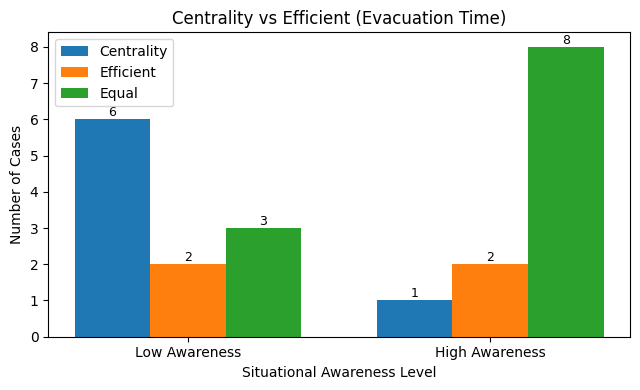

In [32]:
time_df = pd.DataFrame(
    {
        "Centrality": [
            trend_time_summary.loc["Centrality better", "low awareness"],
            trend_time_summary.loc["Centrality better", "high awareness"],
        ],
        "Efficient": [
            trend_time_summary.loc["Efficient better", "low awareness"],
            trend_time_summary.loc["Efficient better", "high awareness"],
        ],
        "Equal": [
            trend_time_summary.loc["Equal", "low awareness"],
            trend_time_summary.loc["Equal", "high awareness"],
        ],
    },
    index=["Low Awareness", "High Awareness"]
)

display(time_df)

plot_centrality_vs_efficient_three_way(
    time_df,
    title="Centrality vs Efficient (Evacuation Time)",
    outname="centrality_vs_efficient_time_3way"
)



## 8) Case-wise ranking table (which strategy is best per case)
This gives you "best strategy per case" and lets you see if one dominates.


In [33]:
# Create a strategy-wise pivot for avg_time
pivot_strategy = df.pivot_table(
    index="case_name",
    columns="strategy",
    values="avg_time",
    aggfunc="mean"
)

# Rank strategies per case (1 = best/lowest time)
ranked = pivot_strategy.rank(axis=1, method="min", ascending=True)

# Identify best strategy label per case
best_strategy = pivot_strategy.idxmin(axis=1)
best_time = pivot_strategy.min(axis=1)

ranking_table = pivot_strategy.copy()
ranking_table["best_strategy"] = best_strategy
ranking_table["best_avg_time"] = best_time

display(ranking_table.sort_values("best_avg_time").head(20))

strategy,high awareness + centrality,high awareness + efficient,low awareness + centrality,low awareness + efficient,best_strategy,best_avg_time
case_name,,,,,,
theme_park_case_3,16.377054,16.377054,16.377054,18.437054,high awareness + centrality,16.377054
theme_park_case_5,16.448036,16.448036,16.448036,16.448036,high awareness + centrality,16.448036
theme_park_case_4,17.231161,17.231161,18.682411,18.682411,high awareness + centrality,17.231161
theme_park_case_2,17.265683,17.476933,17.265683,20.231760,high awareness + centrality,17.265683
theme_park_case_1,19.851786,19.851786,20.822576,20.822576,high awareness + centrality,19.851786
representative_case_theme_park,21.521957,21.521957,22.318207,28.935536,high awareness + centrality,21.521957
theme_park_case_10,24.055821,22.889393,24.055821,23.913179,high awareness + efficient,22.889393
theme_park_case_8,24.054000,23.979000,24.054000,23.979000,high awareness + efficient,23.979000
theme_park_case_9,24.054000,24.054000,24.054000,38.496429,high awareness + centrality,24.054000


## 9) Summary of best-strategy frequency
"How many cases does each strategy win?"


In [34]:
best_strategy_counts = best_strategy.value_counts().rename_axis("strategy").reset_index(name="wins")
display(best_strategy_counts)

,strategy,wins
0,high awareness + centrality,9
1,high awareness + efficient,2


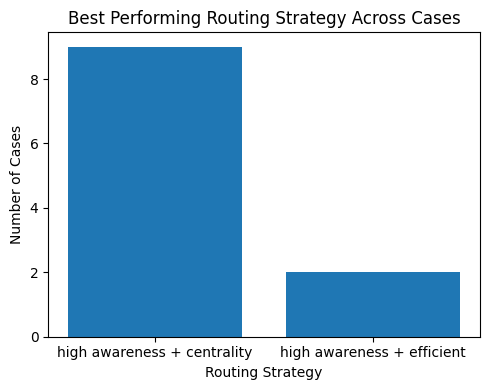

In [35]:
plot_value_counts(
    best_strategy,
    title="Best Performing Routing Strategy Across Cases",
    xlabel="Routing Strategy",
    ylabel="Number of Cases",
    outname="best_strategy_frequency"
)


## 10) Compare by another KPI (mean remaining path risk)
Same structure, but using `mean_remaining_path_risk` (lower is better).


In [36]:
pivot_risk = df.pivot_table(
    index="case_name",
    columns=["awareness", "algorithm"],
    values="mean_remaining_path_risk",   # o "cumulative_risk_exposure"
    aggfunc="mean"
)

display(pivot_risk.head())
print("Pivot columns:", pivot_risk.columns.tolist())

low_c = pivot_risk[("low", "centrality")]
low_e = pivot_risk[("low", "efficient")]

low_c_better = low_c < low_e
low_e_better = low_c > low_e
low_equal    = low_c == low_e

# HIGH awareness
high_c = pivot_risk[("high", "centrality")]
high_e = pivot_risk[("high", "efficient")]

high_c_better = high_c < high_e
high_e_better = high_c > high_e
high_equal    = high_c == high_e


awareness                            high                  low          
algorithm                      centrality efficient centrality efficient
case_name                                                               
representative_case_theme_park   0.043226  0.043226   0.054221  0.065970
theme_park_case_1                0.042321  0.042321   0.050479  0.050479
theme_park_case_10               0.000411  0.000291   0.000380  0.011877
theme_park_case_2                0.037009  0.034512   0.037009  0.056328
theme_park_case_3                0.051056  0.051056   0.051056  0.059678

Pivot columns: [('high', 'centrality'), ('high', 'efficient'), ('low', 'centrality'), ('low', 'efficient')]


In [37]:
trend_risk_summary = pd.DataFrame(
    {
        "low awareness": [
            int(low_c_better.sum()),
            int(low_e_better.sum()),
            int(low_equal.sum()),
        ],
        "high awareness": [
            int(high_c_better.sum()),
            int(high_e_better.sum()),
            int(high_equal.sum()),
        ],
    },
    index=["Centrality better", "Efficient better", "Equal"],
)


,Centrality,Efficient,Equal
Low Awareness,8,0,3
High Awareness,1,2,8


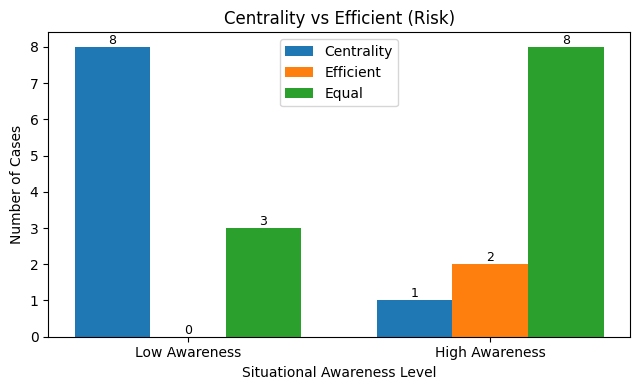

In [38]:
risk_df = pd.DataFrame(
    {
        "Centrality": [
            trend_risk_summary.loc["Centrality better", "low awareness"],
            trend_risk_summary.loc["Centrality better", "high awareness"],
        ],
        "Efficient": [
            trend_risk_summary.loc["Efficient better", "low awareness"],
            trend_risk_summary.loc["Efficient better", "high awareness"],
        ],
        "Equal": [
            trend_risk_summary.loc["Equal", "low awareness"],
            trend_risk_summary.loc["Equal", "high awareness"],
        ],
    },
    index=["Low Awareness", "High Awareness"]
)

display(risk_df)

plot_centrality_vs_efficient_three_way(
    risk_df,
    title="Centrality vs Efficient (Risk)",
    outname="centrality_vs_efficient_risk_3way"
)
